<a href="https://colab.research.google.com/github/Jpablo179804/MineriaDatos/blob/main/Parcial2/largest_islands.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# World's largest islands

This dataset `largest-islands.csv` contains information about the 100 largest islands in the world. The unit for the `area` column is km2.

In [25]:
# FOR GOOGLE COLAB ONLY.
# Uncomment and run the code below. A dialog will appear to upload files.
# Upload 'largest-islands.csv'.

from google.colab import files
uploaded = files.upload()

Saving largest-islands.csv to largest-islands (5).csv


In [26]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('largest-islands.csv')
df.head()

,region,island,area,countries,climate,rank
0,Africa,Madagascar,591896,Madagascar,tropics,4
1,Antarctic,Kerguelen,6200,"Antarctic Lands, France",temperate,91
2,Asia,Sumba,11153,Indonesia,tropics,65
3,Asia,Hainan,34300,China,tropics,37
4,Asia,Taiwan,36198,Taiwan,tropics,36


### Project Ideas

- What are the 10 largest islands in the tropics?

- What are the largest islands in each `region`?

- Create a line graph with `area` on the y-axis and `rank` on the x-axis. The data should be ordered by `rank`, from largest to smallest.

- What islands are composed of multiple countries?
	- Hint: try `countries.str.contains(",")`

¿Cuáles son las 10 islas más grandes en los trópicos?

¿Cuáles son las islas más grandes en cada región?

Gráfico de líneas con el área en el eje Y y el rango (rank) en el eje X.

¿Qué islas están compuestas por múltiples países?

In [27]:
# Filtramos el DataFrame por la condición de clima tropical y obtenemos las 10 con mayor área
top_10_tropics = df[df['climate'] == 'tropics'].nlargest(10, 'area')

# Mostramos el resultado (solo columnas relevantes para mayor claridad)
top_10_tropics[['island', 'area', 'countries']]

,island,area,countries
86,New Guinea,821400,"Papua New Guinea, Indonesia"
23,Borneo,755000,"Indonesia, Malaysia, Brunei"
0,Madagascar,591896,Madagascar
28,Sumatra,480793,Indonesia
22,Sulawesi,188522,Indonesia
21,Java,129438,Indonesia
80,Cuba,109884,Cuba
26,Luzon,104688,Philippines
14,Mindanao,94630,Philippines
73,Hispaniola,76192,"Dominican Republic, Haiti"


In [28]:
# Agrupamos por 'region' y buscamos el índice donde el 'area' es máxima
idx_max_area = df.groupby('region')['area'].idxmax()

# Filtramos el DataFrame usando esos índices y ordenamos para mejor lectura
largest_by_region = df.loc[idx_max_area].sort_values(by='area', ascending=False)

largest_by_region[['region', 'island', 'area', 'countries']]

,region,island,area,countries
41,Europe,Greenland,2166086,Denmark
86,Oceania,New Guinea,821400,"Papua New Guinea, Indonesia"
23,Asia,Borneo,755000,"Indonesia, Malaysia, Brunei"
0,Africa,Madagascar,591896,Madagascar
75,North America,Baffin Island,507451,Canada
35,Eurasia,Sakhalin,76400,Russia
98,South America,Isla Grande de Tierra del Fuego,47992,"Chile, Argentina"
1,Antarctic,Kerguelen,6200,"Antarctic Lands, France"


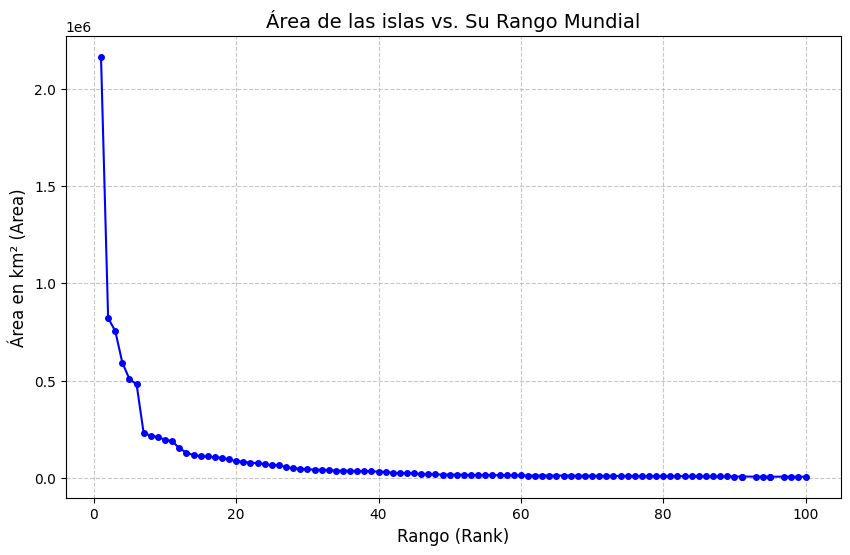

In [29]:
# Ordenamos los datos por rango (rank) de mayor a menor numéricamente (100 a 1)
df_sorted = df.sort_values(by='rank', ascending=False)

# Creamos el gráfico de líneas
plt.figure(figsize=(10, 6))
plt.plot(df_sorted['rank'], df_sorted['area'], color='b', marker='o', markersize=4, linestyle='-')

# Añadimos etiquetas y título
plt.title('Área de las islas vs. Su Rango Mundial', fontsize=14)
plt.xlabel('Rango (Rank)', fontsize=12)
plt.ylabel('Área en km² (Area)', fontsize=12)

# Invertimos el eje X para que el Rank 1 (el más grande) quede a la derecha,
# o puedes dejarlo normal dependiendo de la perspectiva deseada.
# plt.gca().invert_xaxis()

plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [30]:
# Utilizamos str.contains para buscar las comas en la columna de países,
# lo cual indica que hay más de un país listado.
multiple_countries = df[df['countries'].str.contains(",", na=False)]

multiple_countries[['island', 'countries', 'region']]

,island,countries,region
1,Kerguelen,"Antarctic Lands, France",Antarctic
23,Borneo,"Indonesia, Malaysia, Brunei",Asia
45,Ireland,"Ireland, United Kingdom",Europe
50,Cyprus,"Cyprus, United Kingdom",Europe
73,Hispaniola,"Dominican Republic, Haiti",North America
86,New Guinea,"Papua New Guinea, Indonesia",Oceania
98,Isla Grande de Tierra del Fuego,"Chile, Argentina",South America
